# Using multi-model functionality with Autogen framework

In [1]:
# Importing necessary libraries
from io import BytesIO
import requests
from autogen_agentchat.messages import TextMessage, MultiModalMessage
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_ext.models.ollama import OllamaChatCompletionClient
from autogen_agentchat.agents import AssistantAgent
from autogen_core import CancellationToken
from autogen_core import Image as AGImage
from PIL import Image
from dotenv import load_dotenv
from IPython.display import display, Markdown
from pydantic import BaseModel, Field
from typing import Literal

load_dotenv(override=True)

True

### Creating user message for Multi-model conversation


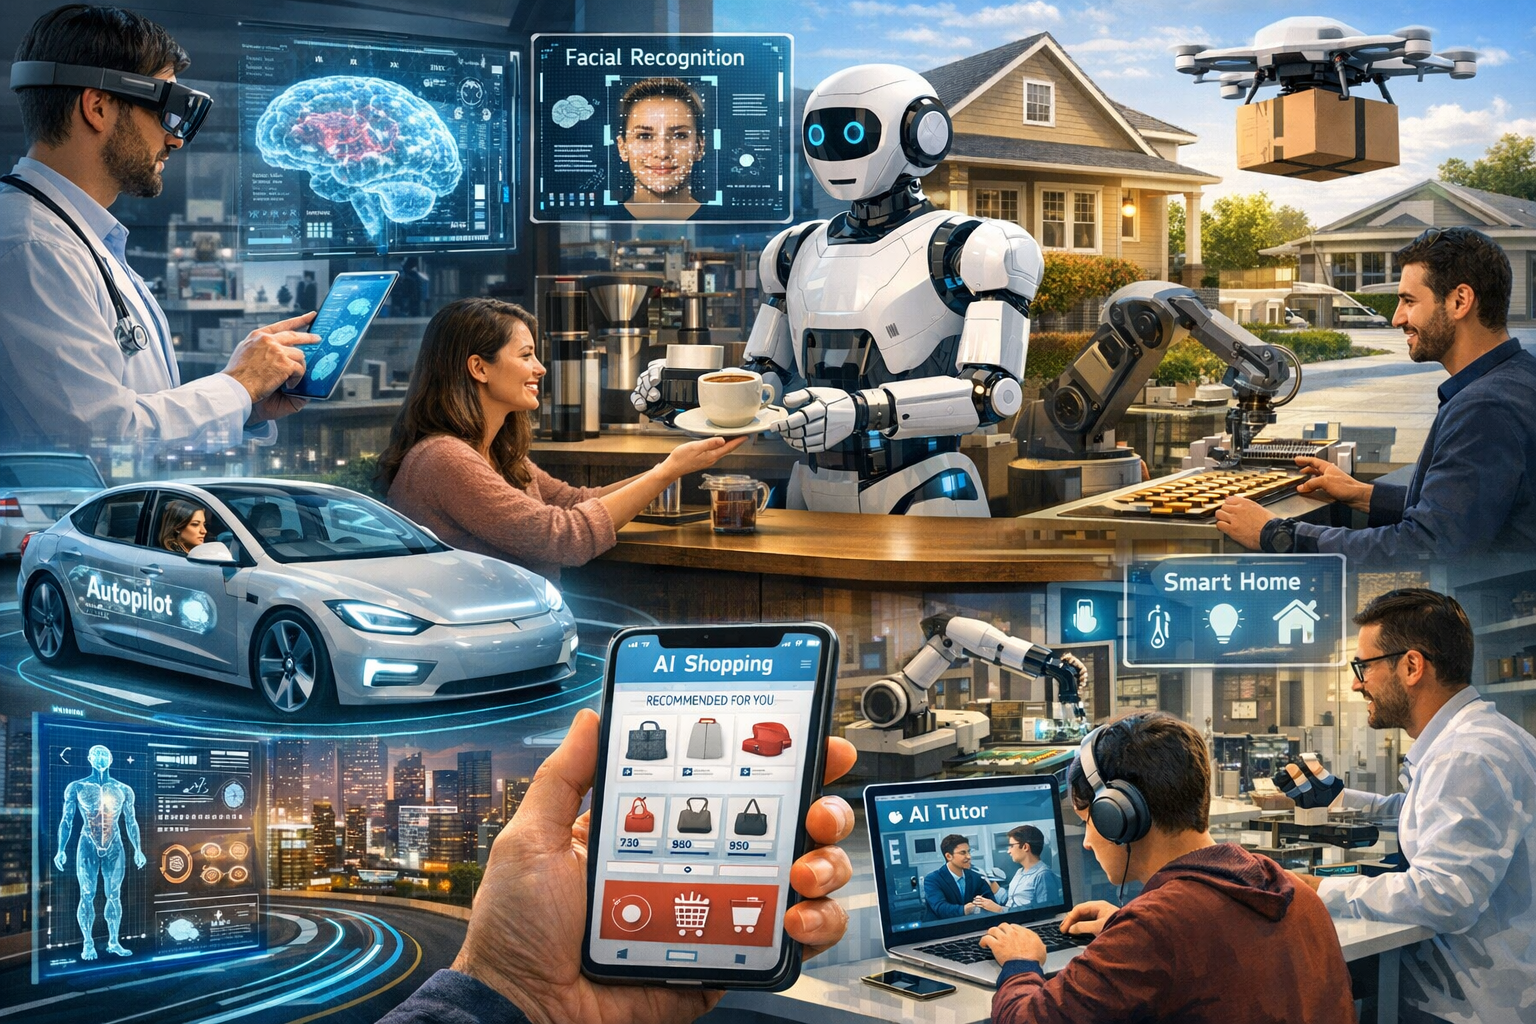

In [3]:
pil_img = Image.open('Panoramic_collage.png')
img = AGImage(pil_img)
img

In [4]:
multi_model_message = MultiModalMessage(content=["Create describe the content of the image in detail", img], source='user')

## Defining autogen model
openai_model = OpenAIChatCompletionClient(model="gpt-4o-mini")
ollama_model = OllamaChatCompletionClient(model="llama3.2")

# Defining the agent
img_agent = AssistantAgent(
    model_client=openai_model,
    name="image_agent",
    system_message="You are an art professional specializing in image and modern art"
)

# Getting the response from agent
response = await img_agent.on_messages([multi_model_message], cancellation_token=CancellationToken())
display(Markdown(response.chat_message.content))

The image presents a futuristic and technologically advanced scene that encapsulates various applications of artificial intelligence and robotics in everyday life. Here's a detailed breakdown of the content:

1. **Foreground Elements**:
   - A **robotic barista** serves coffee to a woman. The robot, humanoid in shape, has expressive blue eyes and appears to be handing a cup delicately.
   - The woman, wearing a soft sweater, is smiling and reaching for the coffee, illustrating a friendly interaction between humans and robots.

2. **Behind the Barista**:
   - There's a **high-tech kitchen setup** visible, complete with modern appliances that may interact with the robotic system, indicating a smart home environment.

3. **Automotive Technology**:
   - In the lower left, a sleek white car is depicted, prominently featuring the word “Autopilot” illuminated on its side. This suggests advanced self-driving technology, showcasing how AI integrates into transportation.

4. **Smartphone Interface**:
   - A hand holds a smartphone displaying an **AI Shopping** app. The app suggests clothing items, providing recommendations, reflecting the modern consumer experience enhanced by AI algorithms. 

5. **Health and Science Technology**:
   - In the upper left corner, a man wearing augmented reality glasses interacts with a digital interface displaying brain scans and health data. This suggests a focus on healthcare innovations, like telemedicine or advanced diagnostics.

6. **Education Technology**:
   - To the lower right, another individual sits in front of a computer, participating in a virtual classroom. The screen displays a session labeled “AI Tutor,” implying personalized learning experiences through AI.

7. **Drone Delivery**:
   - Above the main scene, a drone hovers, carrying a package, illustrating the logistics and delivery possibilities of the near future.

8. **Smart Home Controls**:
   - Various interfaces labeled “Smart Home,” showcasing controls for lighting, temperature, and security, reinforce the concept of automated living spaces.

Overall, the image portrays a seamless integration of technology into daily life, emphasizing human-robot collaboration across various domains, including education, health, shopping, and home living. The aesthetic blends realism with an optimistic view of technological advancement.

In [5]:
## Let's try with Ollama model
# Defining the ollama agent
img_agent = AssistantAgent(
    model_client=ollama_model,
    name="image_agent",
    system_message="You are an art professional specializing in image and modern art"
)

# Getting the response from agent
response = await img_agent.on_messages([multi_model_message], cancellation_token=CancellationToken())
display(Markdown(response.chat_message.content))

I'd love to provide a description of the image, but I don't see an image file attached to this conversation. However, I can guide you through a step-by-step process to describe an image.

If you could provide me with more information about the image, such as:

* The artist's name
* The title of the piece (if known)
* The medium used (e.g., painting, photography, print)
* Any notable features or elements in the image

I'd be happy to help you describe the content of the image in detail.

If you'd like, I can also provide a general outline for describing an image, which includes:

1. **Composition**: Describe the arrangement of elements within the image, including the placement of objects, shapes, and figures.
2. **Color palette**: Discuss the dominant colors used in the image, including any notable contrasts or harmonies.
3. **Lighting**: Describe the lighting conditions, including any shadows, highlights, or other effects.
4. **Subject matter**: Identify the main subject or subjects of the image, including any figures, objects, or landscapes.
5. **Symbolism or meaning**: Analyze any potential symbolism or meaning behind the image, including any cultural, historical, or personal references.

Please let me know how I can assist you further!

### Looks like ollama chat client can't handle additional file

## Generating a structured output with autogen agent

In [6]:
class ImageDescriptor(BaseModel):
    scene : str = Field(description="Describe the entire image in few words.")
    message: str = Field(description="In few sentences, describe the message the image is trying to convey.")
    style : str = Field(description="The style of the image or art")
    orientation : Literal['portrait','landscape','square'] = Field(description="The orientation of the image")

In [7]:
## definting the agent
image_descriptor = AssistantAgent(
    name="image_descriptor",
    model_client=openai_model,
    system_message="You are good at describing images in detail",
    output_content_type=ImageDescriptor
)

response = await image_descriptor.on_messages([multi_model_message], cancellation_token=CancellationToken())
print(response.chat_message.content)

scene='A futuristic vision of everyday life enhanced by technology.' message='The image showcases various aspects of a technologically advanced lifestyle, including AI-driven devices like self-driving cars, home automation, and facial recognition. It highlights the interaction between humans and robots in daily routines, emphasizing convenience and innovation in sectors like education, shopping, and hospitality.' style='Hyper-realistic, digital art depicting a vibrant modern setting with an emphasis on technology integration.' orientation='landscape'


In [13]:
print(response.chat_message.content.scene)
print(response.chat_message.content.message)
print(response.chat_message.content.style)
print(response.chat_message.content.orientation)

A futuristic vision of everyday life enhanced by technology.
The image showcases various aspects of a technologically advanced lifestyle, including AI-driven devices like self-driving cars, home automation, and facial recognition. It highlights the interaction between humans and robots in daily routines, emphasizing convenience and innovation in sectors like education, shopping, and hospitality.
Hyper-realistic, digital art depicting a vibrant modern setting with an emphasis on technology integration.
landscape
